<a href="https://colab.research.google.com/github/nabillahumi/S5-Mesin_Learning/blob/main/Jobsheet5/Tugas%20Praktikum%20(JS5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Pilih salah satu dataset nyata dari sklearn.datasets (misalnya iris dataset atau digits dataset).

In [1]:
# aku memakai iris

from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Ukuran data:", X.shape)
print("Nama fitur:", iris.feature_names)
print("Nama kelas:", iris.target_names)

Ukuran data: (150, 4)
Nama fitur: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nama kelas: ['setosa' 'versicolor' 'virginica']


2. Lakukan clustering dengan HDBSCAN

In [2]:
!pip install hdbscan

In [3]:
import numpy as np
import hdbscan

hdb = hdbscan.HDBSCAN(min_cluster_size=5)
hdb.fit(X)

labels = hdb.labels_

print("Label cluster:", np.unique(labels))

Label cluster: [0 1]


Menampilkan jumlah cluster dan noise

In [4]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Jumlah cluster:", n_clusters)
print("Jumlah noise:", n_noise)

Jumlah cluster: 2
Jumlah noise: 0


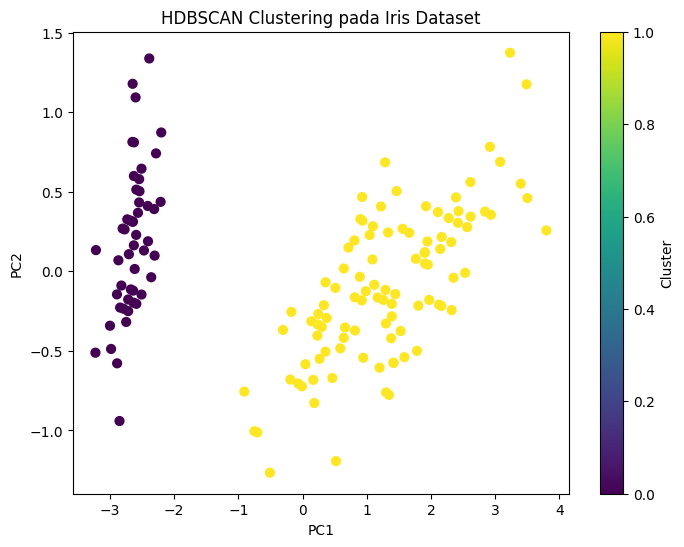

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap="viridis",
    s=40
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("HDBSCAN Clustering pada Iris Dataset")
plt.colorbar(scatter, label="Cluster")
plt.show()

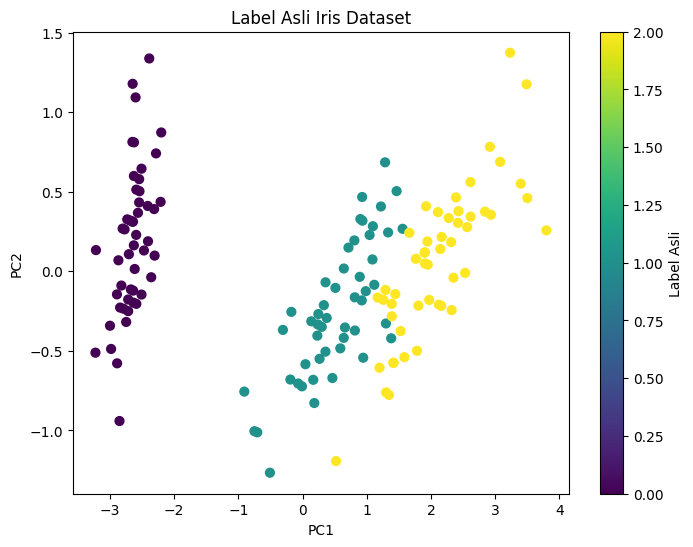

In [6]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    s=40
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Label Asli Iris Dataset")
plt.colorbar(scatter, label="Label Asli")
plt.show()